In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

#                                             Counter : Strike Physics Engine

#### Reason to elaborate on this topic 

In my free time (when there is a possibility to have one), I really enjoy playing video games, especially Counter-Strike. When I saw that there is a chance I can create a (2D, of course) shooting engine to understand a bit further how the damage is calculated in the game, I took the opportunity to do so.

### Plan: 
1. Weapon - characteristics
2. Introduction to Hitscan - shooting representation
3. What happens when the bullet trajectory hits a wall
4. Recoil
5. What happens when the bullet goes through a wallbangable wall? 
6. Utility - grenades and Newton's laws
7. Armor 

## Weapon 
For the purpose of this project, I will use AK-47 (Kalashnikov) - one of the most known Counter:Strike weapon. It will have damage, bullets and recoil.


The weapon has three properties that change during gameplay:
- **bullets** - starts at 30, decreases by 1 with each shot
- **damage** - stays at 36 HP per hit (simplified)
- **recoil** - starts at 0 and increases by 7 every time you fire

Mathematically, if we fire $n$ shots:

$$
\text{bullets}(n) = 30 - n, \qquad \text{recoil}(n) = 7n
$$

The weapon's state after $n$ shots is just the vector $\mathbf{W}(n) = (30 - n,\; 36,\; 7n)$.


In [11]:
class AK47:
    def __init__(self):
        self.bullets = 30
        self.damage = 36
        self.recoil = 0
        self.shot_recoil = 0 

    def shoot(self):
        if self.bullets > 0:
            self.bullets -= 1
            self.shot_recoil = self.recoil 
            self.recoil += 7
            return True
        return False

ak = AK47()
print(f"Fresh AK-47: bullets={ak.bullets}, damage={ak.damage}, recoil={ak.recoil}")
for i in range(3):

    ak.shoot()    
    print(f"  Shot {i+1}: shot_recoil={ak.shot_recoil}, recoil_after={ak.recoil}, bullets={ak.bullets}")

Fresh AK-47: bullets=30, damage=36, recoil=0
  Shot 1: shot_recoil=0, recoil_after=7, bullets=29
  Shot 2: shot_recoil=7, recoil_after=14, bullets=28
  Shot 3: shot_recoil=14, recoil_after=21, bullets=27


## 2. Introduction to Hitscan - shooting representation

In Counter-Strike, bullets do not actually fly through the air. The moment you click, the game draws an invisible line from your position in the direction you are aiming, checks what that line hits, and applies damage instantly. This is called **hitscan**.

Formally, the bullet is a ray starting at the shooter's position $\vec{P}$ going in direction $\hat{D}$:

$$
\vec{R}(t) = \vec{P} + t\,\hat{D}, \qquad t \geq 0
$$

where $t$ is the distance along the ray. Everything here is 2D, so a position is just a tuple $(x, y)$.

We need a few vector operations to make this work:

**Norm** (length of a vector): $\lVert \vec{v} \rVert = \sqrt{v_x^2 + v_y^2}$

**Normalize** (make it length 1): $\hat{v} = \vec{v}\,/\,\lVert \vec{v} \rVert$

**Rotation** by angle $\theta$:

$$
R(\theta)\,\vec{v} = \begin{pmatrix} v_x\cos\theta - v_y\sin\theta \\ v_x\sin\theta + v_y\cos\theta \end{pmatrix}
$$

And the big one - **ray-wall intersection**. A wall is a line segment from point $\vec{A}$ to point $\vec{B}$, parameterized as $\vec{W}(s) = \vec{A} + s(\vec{B} - \vec{A})$ for $s \in [0,1]$. To find where the ray hits the wall, we solve:

$$
\vec{P} + t\,\hat{D} = \vec{A} + s\,\vec{v}
$$

where $\vec{v} = \vec{B} - \vec{A}$. Using Cramer's rule:

$$
t = \frac{(A_x - P_x)\,v_y - (A_y - P_y)\,v_x}{\hat{D}_x\,v_y - \hat{D}_y\,v_x}
$$

If $t \geq 0$ and $s \in [0,1]$, the bullet hits the wall at point $\vec{H} = \vec{P} + t\,\hat{D}$.

In [12]:
def norm(v):
    return math.sqrt(v[0]**2 + v[1]**2)

def normalize(v):
    m = norm(v)
    return (v[0]/m, v[1]/m) if m > 0 else (0.0, 0.0)

def rotate(v, angle_deg):
    r = math.radians(angle_deg)
    c, s = math.cos(r), math.sin(r)
    return (v[0]*c - v[1]*s, v[0]*s + v[1]*c)

def ray_wall_intersection(origin, direction, wall_start, wall_end):
    d = normalize(direction)
    vx = wall_end[0] - wall_start[0]
    vy = wall_end[1] - wall_start[1]

    det = d[0]*vy - d[1]*vx
    if abs(det) < 1e-10:
        return (False, None, None)

    dx = wall_start[0] - origin[0]
    dy = wall_start[1] - origin[1]

    t = (dx*vy - dy*vx) / det
    s = (dx*d[1] - dy*d[0]) / det

    if t >= 0 and 0 <= s <= 1:
        hit = (origin[0] + d[0]*t, origin[1] + d[1]*t)
        return (True, t, hit)

    return (False, None, None)

# quick sanity check: shoot straight right at a vertical wall
hit, t, point = ray_wall_intersection((0, 5), (1, 0), (10, 0), (10, 10))
print(f"Hit: {hit}, distance: {t}, point: ({point[0]:.1f}, {point[1]:.1f})")

Hit: True, distance: 10.0, point: (10.0, 5.0)


Create test figures

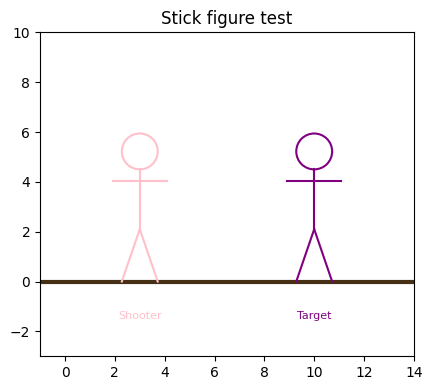

In [13]:
def draw_stickman(ax, x, ground_y, height=6, color='black', label=None):
    head_r = height * 0.12
    body_top = ground_y + height * 0.75
    body_bot = ground_y + height * 0.35
    # head
    circle = plt.Circle((x, body_top + head_r), head_r, fill=False,
                         edgecolor=color, linewidth=1.5, zorder=5)
    ax.add_patch(circle)
    # body
    ax.plot([x, x], [body_top, body_bot], color=color, linewidth=1.5, zorder=5)
    # arms
    ax.plot([x - height*0.18, x + height*0.18],
            [body_top - height*0.08, body_top - height*0.08],
            color=color, linewidth=1.5, zorder=5)
    # legs
    ax.plot([x, x - height*0.12], [body_bot, ground_y], color=color, linewidth=1.5, zorder=5)
    ax.plot([x, x + height*0.12], [body_bot, ground_y], color=color, linewidth=1.5, zorder=5)
    if label:
        ax.text(x, ground_y - 1.5, label, ha='center', fontsize=8, color=color)

# quick test
fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(y=0, color="#463015", linewidth=3)
draw_stickman(ax, 3, 0, height=6, color='pink', label='Shooter')
draw_stickman(ax, 10, 0, height=6, color='purple', label='Target')
ax.set_xlim(-1, 14)
ax.set_ylim(-3, 10)
ax.set_aspect('equal')
ax.set_title('Stick figure test')
plt.tight_layout()
plt.show()

## 3. What happens when the bullet trajectory hits a wall

When you fire the AK-47, the bullet does not go exactly where you are aiming. Each shot adds recoil, which pushes the direction upward, and there is a random horizontal wobble too.

The recoil model works like this:
- **Vertical offset** grows with each shot: \
\
$\theta_v = \frac{7n}{10}$ degrees  

- **Horizontal offset** is random each time: \
\
$\Theta_h \sim \mathcal{U}(-2, 2)$ degrees

Starting from the original aim direction $\vec{D}$, we apply three transformations in order:

$$
\vec{D} \;\xrightarrow{\text{rotate by }\Theta_h}\; \vec{D}_1 \;\xrightarrow{+\,(0,\;\tan\theta_v)}\; \vec{D}_2 \;\xrightarrow{\text{normalize}}\; \hat{D}_{\text{final}}
$$

Then we cast the ray $\vec{R}(t) = \vec{P} + t\,\hat{D}_{\text{final}}$ and find the closest wall it hits.

But what would happen if we did not check for walls at all? The bullet would just fly forever in a straight line, passing through everything. Let's compare the two approaches side by side.

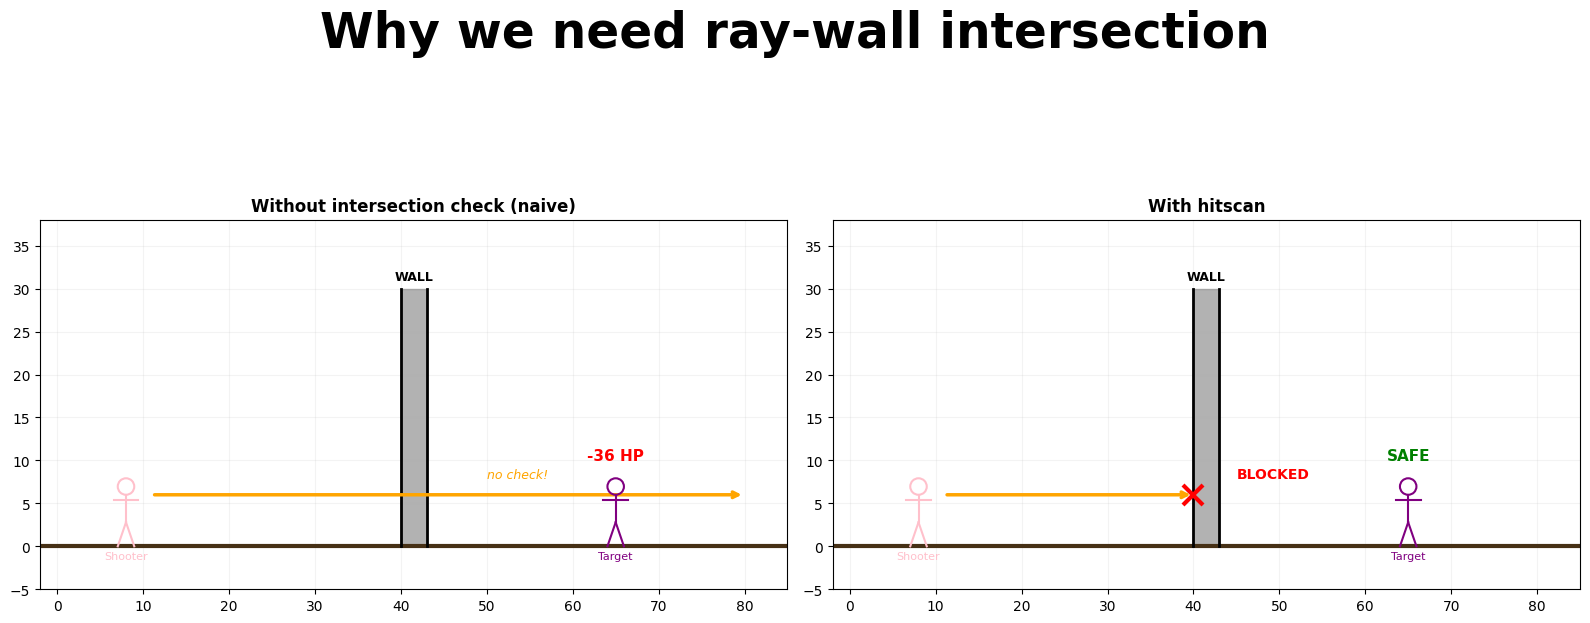

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ground = 0
wall_x = 40

for ax, title, stops_at_wall in [
    (ax1, 'Without intersection check (naive)', False),
    (ax2, 'With hitscan', True)
]:
    
    ax.axhline(y=ground, color='#463015', linewidth=3)

    ax.fill_between([wall_x, wall_x + 3], ground, 30,
                     color='gray', alpha=0.6)
    ax.plot([wall_x, wall_x], [ground, 30], 'k-', linewidth=2)
    ax.plot([wall_x + 3, wall_x + 3], [ground, 30], 'k-', linewidth=2)
    ax.text(wall_x + 1.5, 31, 'WALL', ha='center', fontsize=9, fontweight='bold')

    draw_stickman(ax, 8, ground, height=8, color='pink', label='Shooter')
    draw_stickman(ax, 65, ground, height=8, color='purple', label='Target')

    aim_y = ground + 6
    if stops_at_wall:
        ax.annotate('', xy=(wall_x, aim_y), xytext=(11, aim_y),
                    arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
        ax.plot(wall_x, aim_y, 'rx', markersize=14, markeredgewidth=3, zorder=10)
        ax.text(wall_x + 5, aim_y + 2, 'BLOCKED', fontsize=10, color='red', fontweight='bold')
        ax.text(65, ground + 10, 'SAFE', fontsize=11, color='green', fontweight='bold', ha='center')
    else:
        ax.annotate('', xy=(80, aim_y), xytext=(11, aim_y),
                    arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
        ax.text(65, ground + 10, '-36 HP', fontsize=11, color='red', fontweight='bold', ha='center')
        ax.text(50, aim_y + 2, 'no check!', fontsize=9, color='orange', style='italic')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-2, 85)
    ax.set_ylim(-5, 38)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)

plt.suptitle('Why we need ray-wall intersection', fontsize=35, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Recoil

If we fire many shots, the hit points $\{\vec{H}_1, \vec{H}_2, \ldots, \vec{H}_n\}$ form a spray pattern. We can measure how tight or spread out the pattern is with the **centroid**:

$$
\vec{C}_n = \frac{1}{n}\sum_{i=1}^{n} \vec{H}_i
$$

Because the vertical recoil grows linearly ($7n$), the spray spreads roughly as $\sigma^2 \propto n^2$ .This forms a cone shape.

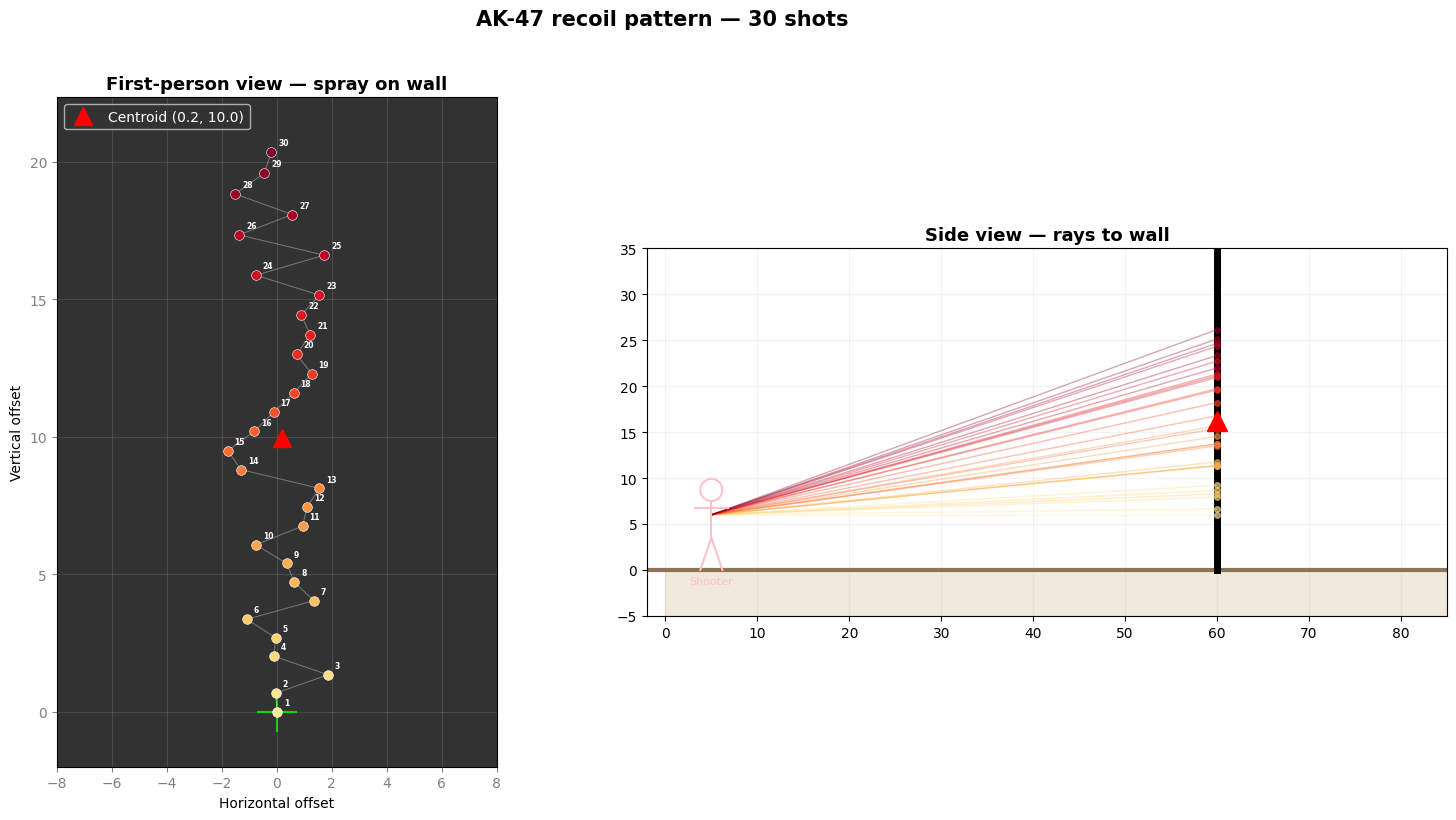

In [15]:
def visualize_recoil_pattern(n_shots=30):
    D = 55.0
    wall_x = 60
    P = (5, 6)
    ground_y = 0
    ak = AK47()

    fp_hits = []      # (h_offset, v_offset) on wall face
    side_hits = []    # (x, y) world coords

    for i in range(n_shots):
        if not ak.shoot():
            break

        if ak.shot_recoil == 0:
            theta_v, theta_h = 0.0, 0.0
        else:
            theta_v = ak.shot_recoil / 10.0
            theta_h = np.random.uniform(-2.0, 2.0)

        # first-person offsets on wall at distance D
        h_off = D * math.tan(math.radians(theta_h))
        v_off = D * math.tan(math.radians(theta_v))
        fp_hits.append((h_off, v_off))

        # side-view ray (same direction, intersect vertical wall)
        if ak.shot_recoil == 0:
            d = normalize((1, 0))
        else:
            d = rotate((1, 0), theta_h)
            d = (d[0], d[1] + math.tan(math.radians(theta_v)))
            d = normalize(d)

        hit, t, pt = ray_wall_intersection(P, d, (wall_x, 0), (wall_x, 40))
        if hit and pt:
            side_hits.append(pt)


    fig, (ax_fp, ax_side) = plt.subplots(1, 2, figsize=(16, 8))

    # === LEFT: first-person spray on the wall ===
    wall_hw = 8
    max_v = max(h[1] for h in fp_hits) if fp_hits else 14
    wall_hh = max_v + 2
    ax_fp.fill_between([-wall_hw, wall_hw], -2, wall_hh,
                        color='#4a4a4a', alpha=0.25)

    # crosshair
    ch = 0.7
    ax_fp.plot([-ch, ch], [0, 0], color='lime', lw=1.5, alpha=0.8)
    ax_fp.plot([0, 0], [-ch, ch], color='lime', lw=1.5, alpha=0.8)

    colors = plt.cm.YlOrRd(np.linspace(0.15, 1.0, len(fp_hits)))

    # spray path line
    if fp_hits:
        ax_fp.plot([h[0] for h in fp_hits], [h[1] for h in fp_hits],
                   '-', color='white', lw=0.7, alpha=0.35)

    for idx, (ho, vo) in enumerate(fp_hits):
        ax_fp.plot(ho, vo, 'o', color=colors[idx], markersize=7,
                   markeredgecolor='white', markeredgewidth=0.4, zorder=5)
        ax_fp.text(ho + 0.25, vo + 0.25, str(idx + 1),
                   fontsize=5.5, color='white', fontweight='bold', zorder=6)

    if fp_hits:
        cx = np.mean([h[0] for h in fp_hits])
        cy = np.mean([h[1] for h in fp_hits])
        ax_fp.plot(cx, cy, 'r^', markersize=13, zorder=10,
                   label=f'Centroid ({cx:.1f}, {cy:.1f})')
        ax_fp.legend(fontsize=10, loc='upper left',
                     facecolor='#333', labelcolor='white')

    ax_fp.set_xlim(-wall_hw, wall_hw)
    ax_fp.set_ylim(-2, wall_hh)
    ax_fp.set_title('First-person view — spray on wall', fontsize=13, fontweight='bold')
    ax_fp.set_xlabel('Horizontal offset')
    ax_fp.set_ylabel('Vertical offset')
    ax_fp.set_facecolor('#2a2a2a')
    ax_fp.tick_params(colors='gray')
    ax_fp.grid(True, alpha=0.12, color='white')
    ax_fp.set_aspect('equal')

    # === RIGHT: side view ===
    ax_side.axhline(y=ground_y, color='#8B7355', linewidth=3)
    ax_side.fill_between([0, 85], -5, ground_y, color='#D2B48C', alpha=0.3)
    ax_side.plot([wall_x, wall_x], [ground_y, 35], 'k-', linewidth=5)

    draw_stickman(ax_side, P[0], ground_y, height=10, color='pink', label='Shooter')

    colors_s = plt.cm.YlOrRd(np.linspace(0.15, 1.0, len(side_hits)))
    for idx, h in enumerate(side_hits):
        ax_side.plot([P[0], h[0]], [P[1], h[1]],
                     color=colors_s[idx], lw=1, alpha=0.35)
        ax_side.plot(h[0], h[1], 'o', color=colors_s[idx], markersize=4, alpha=0.6)

    if side_hits:
        cx_s = np.mean([h[0] for h in side_hits])
        cy_s = np.mean([h[1] for h in side_hits])
        ax_side.plot(cx_s, cy_s, 'r^', markersize=14, zorder=10)

    ax_side.set_title('Side view — rays to wall', fontsize=13, fontweight='bold')
    ax_side.set_xlim(-2, 85)
    ax_side.set_ylim(-5, 35)
    ax_side.grid(True, alpha=0.15)
    ax_side.set_aspect('equal')

    plt.suptitle(f'AK-47 recoil pattern — {n_shots} shots',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_recoil_pattern(30)

## 5. What happens when the bullet goes through a wallbangable wall? What is wallbangable wall in the first place?

The idea is pretty simple: each wall material absorbs a certain percentage of the bullet's energy. The thicker or denser the wall, the more damage it eats. If the bullet still has enough energy left after passing through, it continues and hits whatever (or whoever) is on the other side.

The math behind it:

$$
D_{\text{after}} = D_{\text{before}} \times (1 - k_{\text{mat}} \times d_{\text{wall}})
$$

where $k_{\text{mat}}$ is how much the material absorbs per unit of thickness, and $d_{\text{wall}}$ is how thick it is. The weapon also needs enough raw penetration power to even enter the material in the first place. That calculated looks like:

In [16]:
WEAPONS = [
    ('Glock-18',      1.0,  28),
    ('AK-47',         2.0,  36),
    ('AWP',           2.5, 115),
    ('Desert Eagle',  2.0,  63),
]
TARGET_HP = 100 

MATERIALS = {
    'wood':     {'absorption': 0.15, 'thickness': 1.0, 'threshold': 0.5},
    'drywall':  {'absorption': 0.10, 'thickness': 0.3, 'threshold': 0.3},
    'brick':    {'absorption': 0.30, 'thickness': 2.0, 'threshold': 1.0},
    'concrete': {'absorption': 0.40, 'thickness': 3.0, 'threshold': 1.5},
    'metal':    {'absorption': 0.60, 'thickness': 0.5, 'threshold': 2.0},
    'stone':    {'absorption': 0.70, 'thickness': 4.0, 'threshold': 2.5},
}

def calculate_penetration_damage(initial_damage, weapon_pen, material_name):
    mat = MATERIALS[material_name]

    if weapon_pen < mat['threshold']:
        return (False, 0.0)

    retention = 1.0 - mat['absorption'] * mat['thickness'] * 0.1
    retention = max(retention, 0.0)

    power_ratio = min(weapon_pen / mat['threshold'], 2.0)
    final_factor = retention * (0.5 + 0.5 * (power_ratio / 2.0))

    remaining = initial_damage * final_factor
    if remaining < 5.0:
        return (False, 0.0)

    return (True, remaining)

rows = []
for name, pen, dmg in WEAPONS:
    for mat in MATERIALS:
        can, rem = calculate_penetration_damage(dmg, pen, mat)
        if can:
            shots_to_kill = math.ceil(TARGET_HP / rem)
            rows.append({
                'Weapon': name,
                'Material': mat.capitalize(),
                'Base DMG': dmg,
                'After Wall': f'{rem:.1f}',
                'Loss %': f'{(1 - rem/dmg)*100:.0f}%',
                f'Shots to Kill ({TARGET_HP} HP)': shots_to_kill,
            })
        else:
            rows.append({
                'Weapon': name,
                'Material': mat.capitalize(),
                'Base DMG': dmg,
                'After Wall': 'BLOCKED',
                'Loss %': '—',
                f'Shots to Kill ({TARGET_HP} HP)': '—',
            })

weapon_dmg = pd.DataFrame(rows)
print(f"Wallbang results (target has {TARGET_HP} HP):\n")
print(weapon_dmg.to_string(index=False))

Wallbang results (target has 100 HP):

      Weapon Material  Base DMG After Wall Loss % Shots to Kill (100 HP)
    Glock-18     Wood        28       27.6     2%                      4
    Glock-18  Drywall        28       27.9     0%                      4
    Glock-18    Brick        28       19.7    30%                      6
    Glock-18 Concrete        28    BLOCKED      —                      —
    Glock-18    Metal        28    BLOCKED      —                      —
    Glock-18    Stone        28    BLOCKED      —                      —
       AK-47     Wood        36       35.5     2%                      3
       AK-47  Drywall        36       35.9     0%                      3
       AK-47    Brick        36       33.8     6%                      3
       AK-47 Concrete        36       26.4    27%                      4
       AK-47    Metal        36       26.2    27%                      4
       AK-47    Stone        36    BLOCKED      —                      —
         AWP

Let's visualize that:

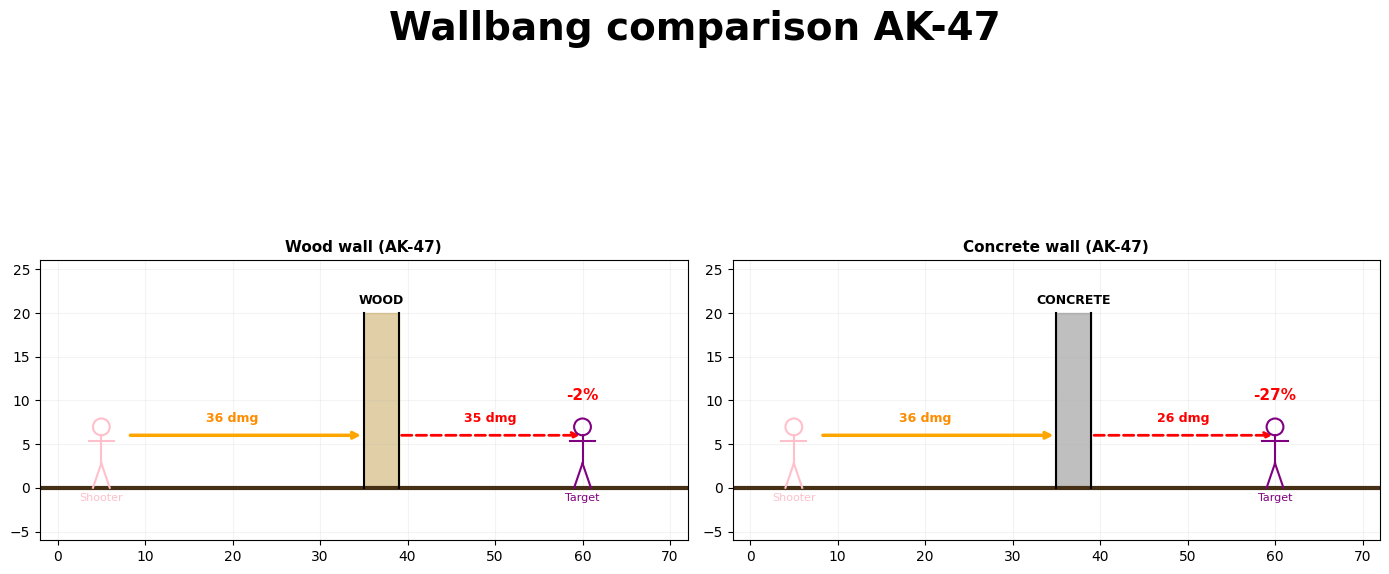

In [17]:

WALL_MATERIAL_1 = 'wood'       # try 'drywall', 'brick', 'metal', etc.
WALL_MATERIAL_2 = 'concrete'   # try 'drywall', 'brick', 'metal', etc.
WEAPON_NAME     = 'AK-47'
WEAPON_PEN      = 2.0
WEAPON_DMG      = 36

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
ground_y = 0
shooter_x, wall_x, wall_w, target_x, ray_y = 5, 35, 4, 60, 6

cases = [
    (f'{WALL_MATERIAL_1.capitalize()} wall ({WEAPON_NAME})', WALL_MATERIAL_1, '#C4A050'),
    (f'{WALL_MATERIAL_2.capitalize()} wall ({WEAPON_NAME})', WALL_MATERIAL_2, '#808080'),
]

for ax, (title, mat, wall_color) in zip(axes, cases):
    can, rem = calculate_penetration_damage(WEAPON_DMG, WEAPON_PEN, mat)

    ax.axhline(y=ground_y, color='#463015', linewidth=3)

    ax.fill_between([wall_x, wall_x + wall_w], ground_y, 20, color=wall_color, alpha=0.5)
    ax.plot([wall_x, wall_x], [ground_y, 20], 'k-', linewidth=1.5)
    ax.plot([wall_x + wall_w, wall_x + wall_w], [ground_y, 20], 'k-', linewidth=1.5)
    ax.text(wall_x + wall_w/2, 21, mat.upper(), ha='center', fontsize=9, fontweight='bold')

    draw_stickman(ax, shooter_x, ground_y, height=8, color='pink', label='Shooter')
    draw_stickman(ax, target_x, ground_y, height=8, color='purple', label='Target')

    ax.annotate('', xy=(wall_x, ray_y), xytext=(shooter_x + 3, ray_y),
                arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
    ax.text((shooter_x + wall_x) / 2, ray_y + 1.5, f'{WEAPON_DMG} dmg',
            ha='center', fontsize=9, color='darkorange', fontweight='bold')

    if can:
        ax.annotate('', xy=(target_x, ray_y), xytext=(wall_x + wall_w, ray_y),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='dashed'))
        ax.text((wall_x + wall_w + target_x) / 2, ray_y + 1.5,
                f'{rem:.0f} dmg', ha='center', fontsize=9, color='red', fontweight='bold')
        loss_pct = (1 - rem / WEAPON_DMG) * 100
        ax.text(target_x, ground_y + 10,
                f'-{loss_pct:.0f}%', ha='center', fontsize=11, color='red', fontweight='bold')
    else:
        ax.plot(wall_x, ray_y, 'rx', markersize=16, markeredgewidth=3, zorder=10)
        ax.text(wall_x + wall_w + 2, ray_y + 1.5, 'BLOCKED', fontsize=10, color='red', fontweight='bold')
        ax.text(target_x, ground_y + 10, 'SAFE', fontsize=11, color='green', fontweight='bold', ha='center')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(-2, 72)
    ax.set_ylim(-6, 26)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)

plt.suptitle(f'Wallbang comparison {WEAPON_NAME}', fontsize=28, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Utility - grenades and Newton's laws

Grenades are a whole different beast compared to bullets. We are now dealing with real physics - gravity pulling them down, air resistance slowing them, and the ground bouncing them back up (or not, depending on how hard they land).

I wanted to simulate this properly, so I used Newton's second law. The total force on a grenade mid-flight is:

$$
\vec{F} = m\vec{g} - \frac{1}{2}\rho\, C_d\, A\, v^2\, \hat{v}
$$

The first part is just gravity pulling it down ($m\vec{g}$). The second part is air dragging - it depends on how fast the grenade is going ($v^2$), how big it is ($A$), and a drag coefficient ($C_d \approx 0.47$ for a sphere, which is close enough for a grenade).

To actually move the grenade through space, I update its position and velocity in small time steps (Euler integration):

$$
\vec{v}(t + \Delta t) = \vec{v}(t) + \vec{a}\,\Delta t, \qquad \vec{x}(t + \Delta t) = \vec{x}(t) + \vec{v}\,\Delta t
$$

When the grenade hits the ground, it bounces - but loses some energy each time (I use a damping factor of 0.6, so it keeps 60% of its speed on each bounce). After a set fuse time, it detonates.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


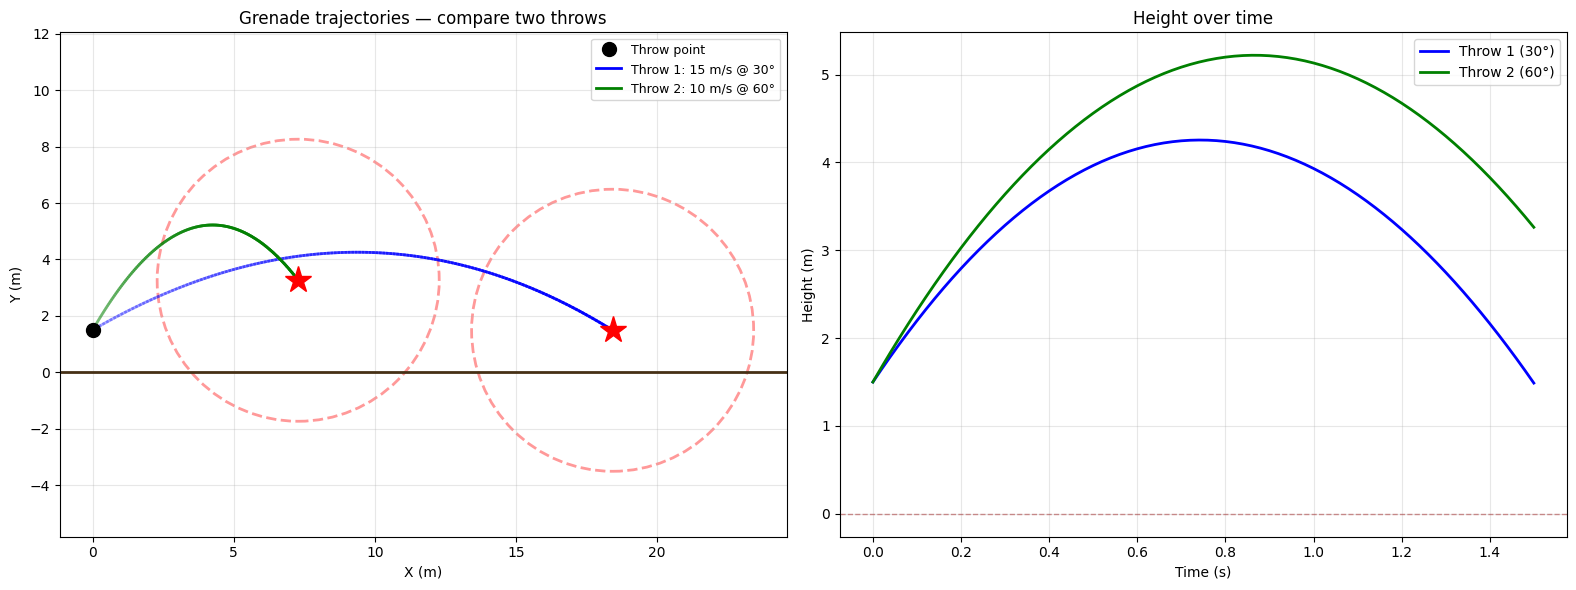

Throw 1 (15 m/s, 30°): lands at x=18.4m, flight=1.50s, max height=4.25m
Throw 2 (10 m/s, 60°): lands at x=7.3m, flight=1.50s, max height=5.22m


In [18]:

THROW_SPEED_1 = 15     # m/s — how hard you throw (try 8, 15, 20)
THROW_ANGLE_1 = 30     # degrees above horizontal (try 20, 45, 70)
THROW_SPEED_2 = 10     #  second throw for comparison
THROW_ANGLE_2 = 60     #  high lob
THROW_HEIGHT  = 1.5    # meters — roughly chest height
FUSE_TIME     = 1.5    # seconds until detonation


GRAVITY = (0.0, -9.81)
AIR_DENSITY = 1.225

def make_grenade(pos, vel, fuse=1.5):
    return {
        'pos': pos, 'vel': vel,
        'mass': 0.4, 'radius': 0.05,
        'drag_coef': 0.47, 'bounce_damp': 0.6,
        'age': 0.0, 'fuse': fuse, 'active': True
    }

def update_grenade(g, dt):
    if not g['active'] or g['age'] >= g['fuse']:
        g['active'] = False
        return

    fx = GRAVITY[0] * g['mass']
    fy = GRAVITY[1] * g['mass']

    speed = math.sqrt(g['vel'][0]**2 + g['vel'][1]**2)
    if speed > 0:
        area = math.pi * g['radius']**2
        drag_mag = 0.5 * AIR_DENSITY * g['drag_coef'] * area * speed**2
        vhat = (g['vel'][0]/speed, g['vel'][1]/speed)
        fx -= drag_mag * vhat[0]
        fy -= drag_mag * vhat[1]

    ax_g = fx / g['mass']
    ay_g = fy / g['mass']

    vx = g['vel'][0] + ax_g * dt
    vy = g['vel'][1] + ay_g * dt
    px = g['pos'][0] + g['vel'][0] * dt + 0.5 * ax_g * dt**2
    py = g['pos'][1] + g['vel'][1] * dt + 0.5 * ay_g * dt**2

    if py <= g['radius']:
        py = g['radius']
        vy = -vy * g['bounce_damp']
        vx *= 0.9

    g['pos'] = (px, py)
    g['vel'] = (vx, vy)
    g['age'] += dt

    if g['age'] >= g['fuse']:
        g['active'] = False

def simulate_grenade(pos, vel, fuse=1.5, dt=0.01):
    g = make_grenade(pos, vel, fuse)
    positions = [g['pos']]
    times = [0.0]
    while g['active']:
        update_grenade(g, dt)
        positions.append(g['pos'])
        times.append(g['age'])
    return positions, times

def throw_vel(speed, angle_deg):
    rad = math.radians(angle_deg)
    return (speed * math.cos(rad), speed * math.sin(rad))

# simulate both throws
pos = (0, THROW_HEIGHT)
vel1 = throw_vel(THROW_SPEED_1, THROW_ANGLE_1)
vel2 = throw_vel(THROW_SPEED_2, THROW_ANGLE_2)

positions1, times1 = simulate_grenade(pos, vel1, FUSE_TIME)
positions2, times2 = simulate_grenade(pos, vel2, FUSE_TIME)

xs1 = [p[0] for p in positions1]; ys1 = [p[1] for p in positions1]
xs2 = [p[0] for p in positions2]; ys2 = [p[1] for p in positions2]
det1, det2 = positions1[-1], positions2[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.axhline(y=0, color='#463015', linewidth=2)

for i in range(len(positions1) - 1):
    alpha = 0.3 + 0.7 * (i / len(positions1))
    ax1.plot(xs1[i:i+2], ys1[i:i+2], 'b-', alpha=alpha, linewidth=2)
ax1.plot(det1[0], det1[1], 'r*', markersize=20, zorder=10)
circle1 = plt.Circle(det1, 5.0, color='red', fill=False, linewidth=2, linestyle='--', alpha=0.4)
ax1.add_patch(circle1)

for i in range(len(positions2) - 1):
    alpha = 0.3 + 0.7 * (i / len(positions2))
    ax1.plot(xs2[i:i+2], ys2[i:i+2], 'g-', alpha=alpha, linewidth=2)
ax1.plot(det2[0], det2[1], 'r*', markersize=20, zorder=10)
circle2 = plt.Circle(det2, 5.0, color='red', fill=False, linewidth=2, linestyle='--', alpha=0.4)
ax1.add_patch(circle2)

ax1.plot(pos[0], pos[1], 'ko', markersize=10, label='Throw point')
ax1.plot([], [], 'b-', linewidth=2, label=f'Throw 1: {THROW_SPEED_1} m/s @ {THROW_ANGLE_1}°')
ax1.plot([], [], 'g-', linewidth=2, label=f'Throw 2: {THROW_SPEED_2} m/s @ {THROW_ANGLE_2}°')
ax1.legend(fontsize=9)
ax1.set_xlabel('X (m)'); ax1.set_ylabel('Y (m)')
ax1.set_title('Grenade trajectories — compare two throws')
ax1.grid(True, alpha=0.3); ax1.axis('equal')
ax1.set_ylim(-1, max(max(ys1), max(ys2)) + 2)

# --- height over time
ax2.plot(times1, ys1, 'b-', linewidth=2, label=f'Throw 1 ({THROW_ANGLE_1}°)')
ax2.plot(times2, ys2, 'g-', linewidth=2, label=f'Throw 2 ({THROW_ANGLE_2}°)')
ax2.axhline(y=0, color='brown', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Height (m)')
ax2.set_title('Height over time')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

dist1 = math.sqrt((det1[0]-pos[0])**2 + (det1[1]-pos[1])**2)
dist2 = math.sqrt((det2[0]-pos[0])**2 + (det2[1]-pos[1])**2)
print(f"Throw 1 ({THROW_SPEED_1} m/s, {THROW_ANGLE_1}°): lands at x={det1[0]:.1f}m, flight={times1[-1]:.2f}s, max height={max(ys1):.2f}m")
print(f"Throw 2 ({THROW_SPEED_2} m/s, {THROW_ANGLE_2}°): lands at x={det2[0]:.1f}m, flight={times2[-1]:.2f}s, max height={max(ys2):.2f}m")

### Grenade damage

The damage from the explosion falls off linearly - the closer you are, the more it hurts:

$$
D(r) = D_{\max} \times \max\!\left(1 - \frac{r}{R_{\max}},\; 0\right)
$$

where $D_{\max} = 98$ HP (a direct hit from an HE grenade) and $R_{\max} \approx 5$ meters (anything further and you take zero damage). So standing right on top of it is basically instant death (98 out of 100 HP), but if you are 3 meters away you only take about 40. 

In [19]:
EXPLOSION_X    = 0.0   
EXPLOSION_Y    = 0.0
BLAST_RADIUS   = 5.0    
MAX_GRENADE_DMG = 98.0  

PLAYER_DISTANCES = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]  
PLAYER_HP        = 100

def grenade_damage(explosion, target, max_dmg=98.0, max_r=5.0):
    d = math.sqrt((target[0]-explosion[0])**2 + (target[1]-explosion[1])**2)
    if d > max_r:
        return 0.0
    return max_dmg * max(1.0 - d / max_r, 0.0)

explosion = (EXPLOSION_X, EXPLOSION_Y)

survival_rows = []
for dist in PLAYER_DISTANCES:
    dmg = grenade_damage(explosion, (explosion[0] + dist, explosion[1]), MAX_GRENADE_DMG, BLAST_RADIUS)
    hp_left = max(PLAYER_HP - dmg, 0)
    alive = 'ALIVE' if hp_left > 0 else 'DEAD'
    survival_rows.append({'Distance (m)': dist, 'Damage': f'{dmg:.1f}', 'HP Left': f'{hp_left:.1f}', 'Status': alive})

print("Survival summary:")
survival_graph = pd.DataFrame(survival_rows)
print(survival_graph.to_string(index=False))

Survival summary:
 Distance (m) Damage HP Left Status
          1.0   78.4    21.6  ALIVE
          2.0   58.8    41.2  ALIVE
          3.0   39.2    60.8  ALIVE
          4.0   19.6    80.4  ALIVE
          5.0    0.0   100.0  ALIVE
          6.0    0.0   100.0  ALIVE


## 7. Simple armor and full armor - damage reduction

Armor system:

* Kevlar vest absorbs a portion of body-shot damage. The amount absorbed depends on the weapon's armor penetration ratio. If the armor penetration ratio is higher that means the bullet ignores more of the armor.
* Helmet  without a helmet, most rifles one-tap you in the head. With a helmet, only the AWP and Deagle still kill in one shot.

The formula for armored damage is:

$$
D_{\text{final}} = D_{\text{base}} \times \left(1 - \frac{(1 - \text{AP\_ratio})}{2}\right)
$$

where $\text{AP\_ratio}$ is the weapon's armor penetration (0 to 1). A higher AP ratio means the armor blocks less.

The armor itself also takes damage when it absorbs a hit:

$$
\text{armor\_damage} = \frac{D_{\text{base}} \times (1 - \text{AP\_ratio})}{2}
$$

Once an armor is broken, you are back to taking full damage. Let's calculate:

In [ ]:
STARTING_ARMOR = 100      
PLAYER_HP_ARMOR = 100     


ARMOR_WEAPONS = [
    ('Glock-18',      28,  0.47, 4.0),
    ('AK-47',         36,  0.775, 4.0),
    ('M4A4',          33,  0.70, 4.0),
    ('AWP',          115,  0.975, 4.0),
    ('Desert Eagle',  63,  0.932, 4.0),
]

def apply_armor(base_damage, ap_ratio, has_armor):
    if not has_armor:
        return base_damage, 0.0
    armor_reduction = (1.0 - ap_ratio) / 2.0
    final_damage = base_damage * (1.0 - armor_reduction)
    armor_cost = base_damage * armor_reduction * 0.5
    return round(final_damage, 1), round(armor_cost, 1)

rows = []
for name, base_dmg, ap_ratio, hs_mult in ARMOR_WEAPONS:
    head_dmg = base_dmg * hs_mult

    body_no_armor = base_dmg
    body_armor, body_armor_cost = apply_armor(base_dmg, ap_ratio, True)

    head_no_helmet = head_dmg
    head_helmet, head_armor_cost = apply_armor(head_dmg, ap_ratio, True)

    rows.append({
        'Weapon': name,
        'Body (no armor)': body_no_armor,
        'Body (kevlar)': body_armor,
        'Armor used': body_armor_cost,
        'Head (no helmet)': head_no_helmet,
        'Head (helmet)': round(head_helmet, 1),
        'Kills through helmet?': 'YES' if head_helmet >= PLAYER_HP_ARMOR else 'NO'
    })

damage_to_armor = pd.DataFrame(rows)
print(f"Damage comparison (player has {PLAYER_HP_ARMOR}HP,{STARTING_ARMOR} armor):\n")
print(damage_to_armor.to_string(index=False))